# ForecastIQ — Exploratory Data Analysis

**AI-Powered Sales Forecasting & Business Analytics Platform**

This notebook explores the ForecastIQ data warehouse built from the *Global Superstore* dataset
(Orders, People, Returns). It walks through the dataset, the shape of the business, distributions,
correlations, trends, and the conclusions that motivate the forecasting layer.

**Contents**
1. Dataset overview
2. Business understanding
3. Distributions
4. Correlations
5. Trends & seasonality
6. Customers & returns
7. Business conclusions

> All figures are computed live from `forecastiq.db` via the tested `forecastiq.analytics` modules —
> no numbers are hardcoded. Run the ETL (`python pipelines/run_etl.py`) first to populate the warehouse.


In [1]:
# --- Setup -------------------------------------------------------------------
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src" / "forecastiq").exists():
            return p
    return start

ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT / "src"))

from forecastiq.config import Config
from forecastiq.utils.io import get_engine, query_df
from forecastiq.analytics import kpis, trends, segmentation, products, regional, returns, insights

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
ACCENT, ACCENT2 = "#2563eb", "#f59e0b"

cfg = Config.load()
engine = get_engine(cfg.db_url)
print("Connected to", cfg.db_url)


Connected to sqlite:///C:/Users/aryav/OneDrive/Desktop/ForecastIQ/forecastiq.db


## 1. Dataset overview

Warehouse tables, time span, and the headline KPIs.

In [2]:
tables = ["dim_date", "dim_customer", "dim_product", "dim_region", "fact_sales"]
counts = {t: query_df(f"SELECT COUNT(*) AS n FROM {t}", engine)["n"].iloc[0] for t in tables}
print("Row counts:")
for t, n in counts.items():
    print(f"  {t:14} {n:>8,}")

span = query_df("SELECT MIN(full_date) lo, MAX(full_date) hi FROM dim_date", engine).iloc[0]
print(f"\nDate span: {span['lo']} -> {span['hi']}")

kpi = kpis.executive_kpis(engine)
print("\nExecutive KPIs:")
for k, v in kpi.items():
    print(f"  {k:20} {v:,.2f}" if isinstance(v, float) else f"  {k:20} {v:,}")


Row counts:
  dim_date          1,468
  dim_customer      1,590
  dim_product      10,768
  dim_region        3,819
  fact_sales       51,290

Date span: 2011-01-01 -> 2015-01-07

Executive KPIs:
  total_revenue        12,642,501.91
  total_profit         1,467,457.29
  profit_margin_pct    11.61
  total_orders         25,035
  total_customers      1,590
  total_units          178,312
  avg_order_value      504.99
  avg_selling_price    70.90
  return_rate_pct      4.68


## 2. Business understanding

Global Superstore is a multi-category retailer operating across seven macro markets. Revenue is split
across **Technology, Furniture and Office Supplies**, sold into **Consumer, Corporate and Home Office**
segments. Below, revenue and margin by category and market frame where the money — and the profit — comes from.


,category,revenue,profit,units,orders,profit_margin_pct
0,Technology,4744557.50,663778.73,35176,8354,13.99
1,Furniture,4110874.19,285204.72,34954,8195,6.94
2,Office Supplies,3787070.23,518473.83,108182,19003,13.69


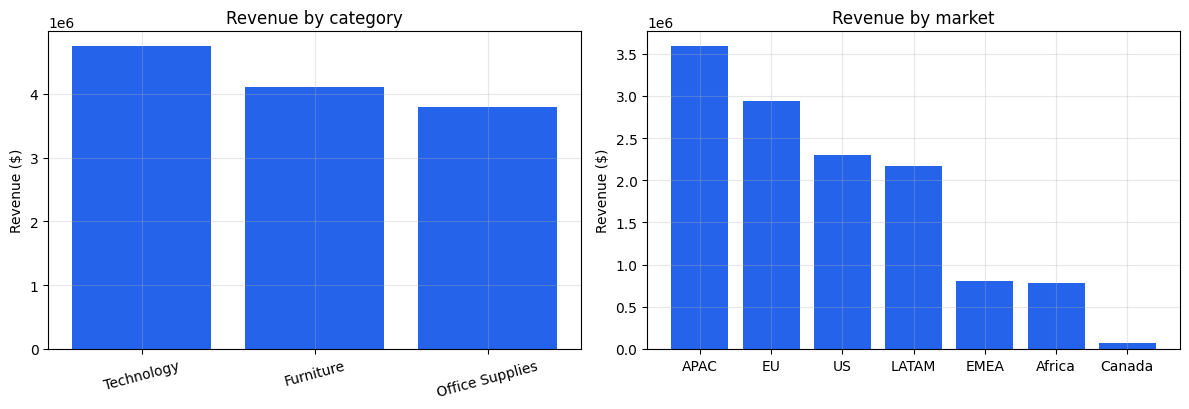

Profit margin by category (%):
       category  profit_margin_pct
     Technology              13.99
      Furniture               6.94
Office Supplies              13.69


In [3]:
cat = products.category_performance(engine)
mkt = regional.market_performance(engine)
display(cat)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(cat["category"], cat["revenue"], color=ACCENT)
ax[0].set_title("Revenue by category"); ax[0].set_ylabel("Revenue ($)")
for lbl in ax[0].get_xticklabels():
    lbl.set_rotation(15)
ax[1].bar(mkt["market"], mkt["revenue"], color=ACCENT)
ax[1].set_title("Revenue by market"); ax[1].set_ylabel("Revenue ($)")
plt.tight_layout(); plt.show()

print("Profit margin by category (%):")
print(cat[["category", "profit_margin_pct"]].to_string(index=False))


## 3. Distributions

The line-level measures are highly skewed — most orders are small, with a long tail of large ones.
Discounts cluster at a few standard levels, and profit is roughly symmetric around zero with heavy tails
(discounting can push individual lines into a loss).

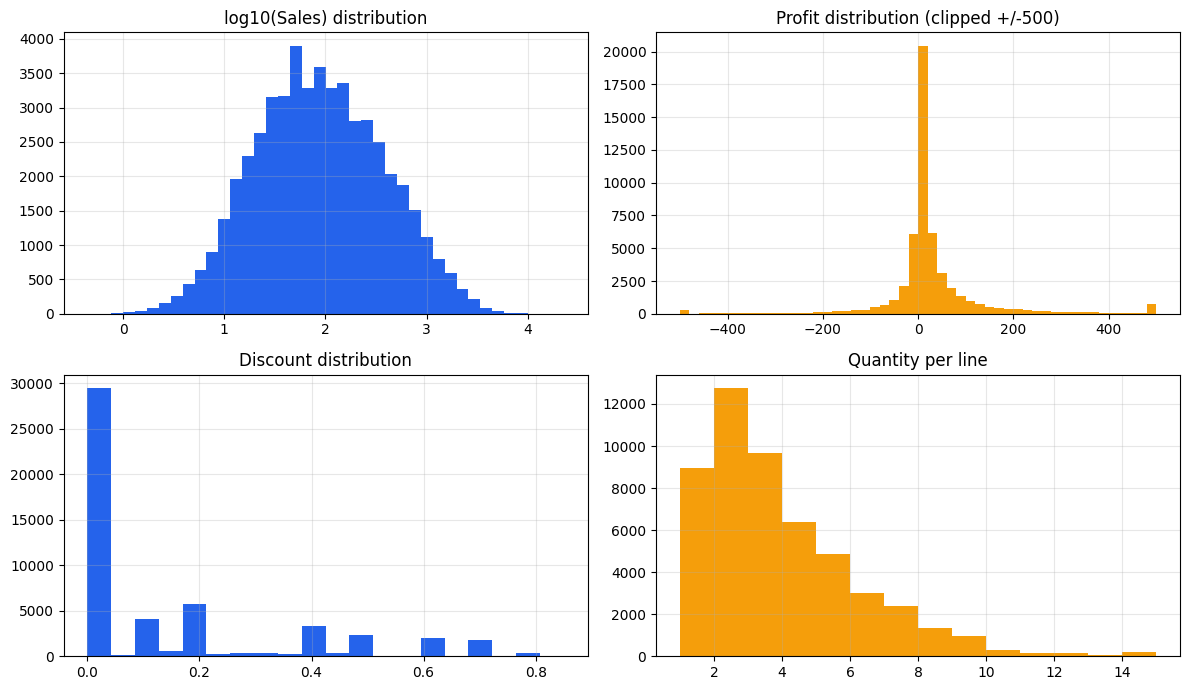

          sales  quantity  discount    profit  shipping_cost
count  51290.00  51290.00  51290.00  51290.00       51290.00
mean     246.49      3.48      0.14     28.61          26.38
std      487.57      2.28      0.21    174.34          57.30
min        0.44      1.00      0.00  -6599.98           0.00
25%       30.76      2.00      0.00      0.00           2.61
50%       85.05      3.00      0.00      9.24           7.79
75%      251.05      5.00      0.20     36.81          24.45
max    22638.48     14.00      0.85   8399.98         933.57


In [4]:
fact = query_df("SELECT sales, quantity, discount, profit, shipping_cost FROM fact_sales", engine)

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0, 0].hist(np.log10(fact["sales"].clip(lower=0.1)), bins=40, color=ACCENT)
ax[0, 0].set_title("log10(Sales) distribution")
ax[0, 1].hist(fact["profit"].clip(-500, 500), bins=50, color=ACCENT2)
ax[0, 1].set_title("Profit distribution (clipped +/-500)")
ax[1, 0].hist(fact["discount"], bins=20, color=ACCENT)
ax[1, 0].set_title("Discount distribution")
ax[1, 1].hist(fact["quantity"], bins=range(1, 16), color=ACCENT2)
ax[1, 1].set_title("Quantity per line")
plt.tight_layout(); plt.show()

print(fact.describe().round(2).to_string())


## 4. Correlations

How the numeric measures move together. The notable signal is the **negative discount ↔ profit**
relationship — deeper discounts erode profit — while sales, quantity and shipping cost are mildly positive.

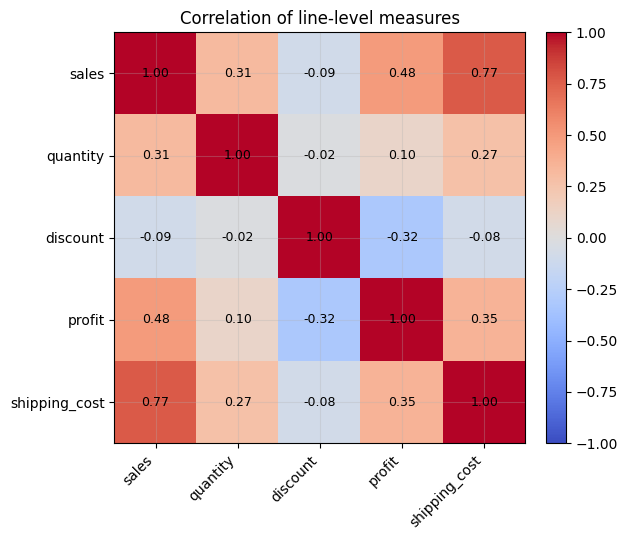

In [5]:
corr = fact.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Correlation of line-level measures")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()


## 5. Trends & seasonality

Revenue trends upward year over year. Aggregating by calendar month across all years exposes a clear
**seasonal pattern**, with the strongest months late in the year — exactly the structure a seasonal
forecasting model (SARIMA) is designed to capture.

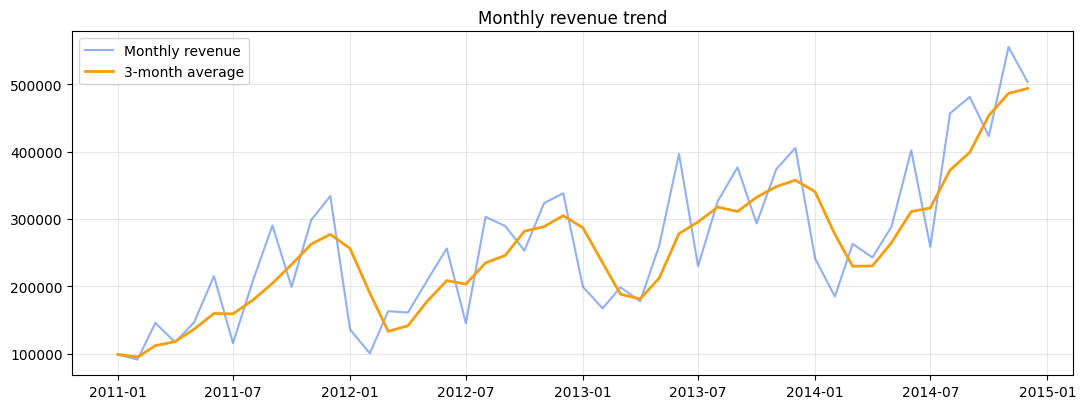

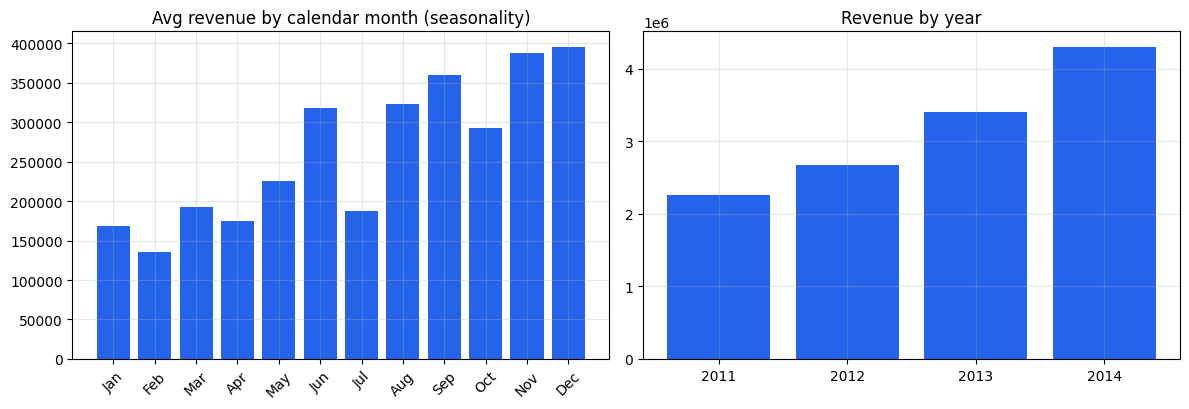

 year    revenue    profit  orders  yoy_growth_pct
 2011 2259450.90 248940.81    4440             NaN
 2012 2677438.69 307415.28    5343           18.50
 2013 3405746.45 406935.23    6721           27.20
 2014 4299865.87 504165.97    8531           26.25


In [6]:
monthly = trends.monthly_revenue(engine).copy()
monthly["period_start"] = pd.to_datetime(monthly["period_start"])
monthly["roll3"] = monthly["revenue"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(monthly["period_start"], monthly["revenue"], color=ACCENT, alpha=0.5, label="Monthly revenue")
ax.plot(monthly["period_start"], monthly["roll3"], color=ACCENT2, lw=2, label="3-month average")
ax.set_title("Monthly revenue trend"); ax.legend(); plt.tight_layout(); plt.show()

season = query_df(
    "SELECT d.month, d.month_name, SUM(f.sales) rev, COUNT(DISTINCT d.year) yrs "
    "FROM fact_sales f JOIN dim_date d ON f.order_date_key=d.date_key GROUP BY d.month, d.month_name",
    engine).sort_values("month")
season["avg_rev"] = season["rev"] / season["yrs"]

yearly = trends.yearly_revenue(engine)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(season["month_name"].str[:3], season["avg_rev"], color=ACCENT)
ax[0].set_title("Avg revenue by calendar month (seasonality)")
for lbl in ax[0].get_xticklabels():
    lbl.set_rotation(45)
ax[1].bar(yearly["year"].astype(str), yearly["revenue"], color=ACCENT)
ax[1].set_title("Revenue by year"); plt.tight_layout(); plt.show()
print(yearly.to_string(index=False))


## 6. Customers & returns

RFM segmentation groups customers by Recency, Frequency and Monetary value. Returns are concentrated in
specific regions — a margin risk worth monitoring.

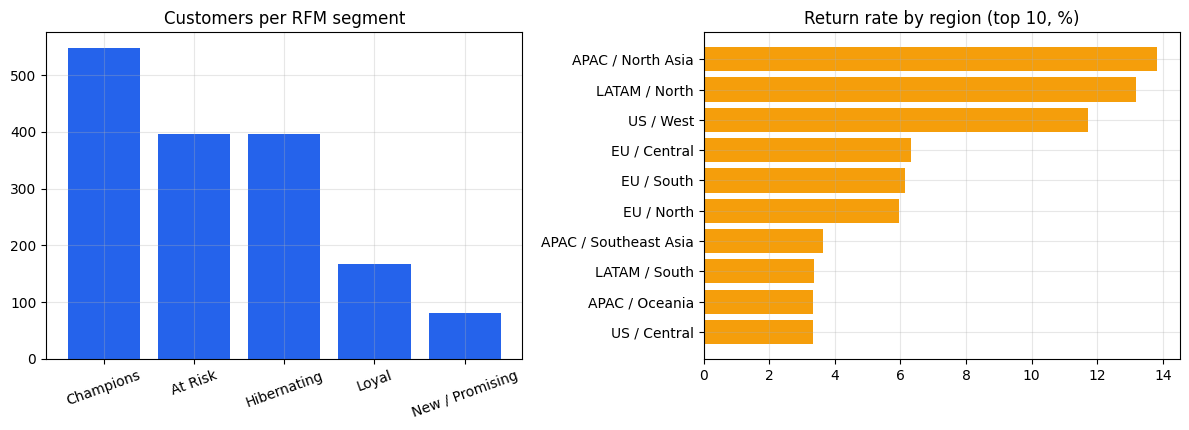

,rfm_segment,customers,revenue,avg_monetary
1,Champions,548,7865263.98,14352.67
0,At Risk,397,3190069.43,8035.44
2,Hibernating,397,951545.88,2396.84
3,Loyal,167,505027.85,3024.12
4,New / Promising,81,130594.91,1612.28


In [7]:
seg = segmentation.rfm_segment_summary(engine)
ret = returns.return_rate_by_region(engine).head(10)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].bar(seg["rfm_segment"], seg["customers"], color=ACCENT)
ax[0].set_title("Customers per RFM segment")
for lbl in ax[0].get_xticklabels():
    lbl.set_rotation(20)
ax[1].barh(ret["market"] + " / " + ret["region"], ret["return_rate_pct"], color=ACCENT2)
ax[1].set_title("Return rate by region (top 10, %)"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()
display(seg)


## 7. Business conclusions

The insights below are generated programmatically by the rule-based engine (`analytics/insights.py`) —
they update automatically as the data changes.

In [8]:
for ins in insights.generate_insights(engine):
    print(f"[{ins.category.upper():11}] {ins.title}")
    print(f"             {ins.detail}\n")


[GROWTH     ] Fastest-growing category: Office Supplies
             Office Supplies revenue grew 29.2% in 2014 vs 2013.

[REGIONAL   ] Best-performing region: Central (EU)
             Central leads on revenue at $1,720,553 (12.5% margin).

[REGIONAL   ] Weakest margin region: Southeast Asia (APAC)
             Southeast Asia has the thinnest margin among major regions at 2.0% on $884,423 revenue.

[RETURNS    ] Highest-returning product: Binney & Smith Sketch Pad, Water Color
             Binney & Smith Sketch Pad, Water Color has a 15.0% return rate over 20 orders (min 20 orders considered).

[SEASONALITY] Seasonal peak in December
             December is the strongest month on average (~50% above the typical month).

[OPPORTUNITY] High-profit opportunity: Accessories
             Accessories (Technology) earns a 17.3% margin on $749,237 revenue - a candidate to scale.

[RISK       ] 3031 loss-making products
             3031 products post negative profit, eroding $558,758 in tota

### Takeaways

- Revenue grows steadily year over year with a pronounced late-year seasonal peak — a strong case for
  **seasonal time-series forecasting**.
- **Technology** and **Office Supplies** carry healthy margins; **Furniture** is a margin laggard.
- Discounting is inversely related to profit — a lever to watch.
- A small set of products and regions drive most **returns** and **losses**, offering targeted upside.

These observations motivate **Phase 3 — Forecasting**, where monthly revenue/demand is projected forward
with ARIMA/SARIMA and ML models, selected by out-of-sample accuracy.
